# Cheese perception — cheese factory (Isaac Sim)

The perception block of the challenge: **a camera frame goes in, a sorting label
comes out**, and the downstream pipeline uses it to drive the arm.

```
Isaac Sim camera ──▶ CheeseClassifier.predict(frame) ──▶ Prediction(label, confidence) ──▶ arm control
```

This notebook covers: the state of the normalised data, a data-leak trap in
CHEESE-HIDB, how the models perform, the render pipeline that moves the training
data into the target domain, and the inference call as the simulation will make it.

**Section 8 has the video**: the model driving a full sorting line in Isaac Sim, one
output lane per class.

> The notebook is **runnable as is** in this web app: the `python3` kernel sees both
> H100s and the project is copied under `/workspace/cheese`. It also runs on the host
> (`/home/nvidia/hpe/cheese`) — the first cell detects the path on its own.

In [1]:
import sys, json, collections, warnings, random, csv, re
from pathlib import Path

# The notebook runs either on the host or inside the Jupyter container, where the
# project is copied under /workspace. Take whichever path exists.
PROJECT = next(p for p in (Path('/home/nvidia/hpe/cheese'), Path('/workspace/cheese'))
               if p.exists())
sys.path.insert(0, str(PROJECT / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

print('project    ', PROJECT)
print('python     ', sys.version.split()[0])
print('torch      ', torch.__version__, '| cuda', torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print(f'  gpu {i}      ', torch.cuda.get_device_name(i))

project     /home/nvidia/hpe/cheese
python      3.12.3
torch       2.6.0+cu124 | cuda True
  gpu 0       NVIDIA H100 NVL
  gpu 1       NVIDIA H100 NVL


## 1. The normalised data

Three heterogeneous sources brought into a single format by `src/normalize.py`:
RGB JPEG, long side 512, EXIF-rotated, de-duplicated, and one CSV manifest.

| source | content |
|---|---|
| [CHEESE-HIDB](https://github.com/andrealoddo/CHEESE-HIDB) | industrial wheels, 6016×4016, product × ripeness |
| [NoeFlandre/cheese-images](https://huggingface.co/datasets/NoeFlandre/cheese-images) | web photos, 290 varieties |
| [Food Recognition 2022](https://datasetninja.com/food-recognition) | meal scenes with polygon annotations |

In [2]:
from dataset import load_manifest, build_label_space, TASKS

rows = load_manifest()
stats = json.loads((PROJECT / 'data/processed/stats.json').read_text())

print(f'{len(rows)} normalised images\n')
for src, info in stats['per_source'].items():
    sp = info['splits']
    print(f"{src:18s} {info['images']:5d} img  {info['classes']:4d} classes  "
          f"train/val/test = {sp.get('train',0)}/{sp.get('val',0)}/{sp.get('test',0)}")

cs = stats['channel_stats']
print('\nnormalisation (computed on the train split only)')
print(f"  mean {cs['mean']}")
print(f"  std  {cs['std']}")

6486 normalised images

cheese_hidb          378 img     6 classes  train/val/test = 128/126/124
cheese_images       3211 img   288 classes  train/val/test = 2257/477/477
food_recognition    2897 img    12 classes  train/val/test = 2041/433/423

normalisation (computed on the train split only)
  mean [0.57893, 0.5269, 0.45318]
  std  [0.27042, 0.26677, 0.27936]


### Available tasks

The three datasets have **incompatible label spaces** — no image carries all three
kinds of label, so they are not force-merged. Several heads are exposed instead.
The one that matters for the robot is `bin`.

Merging them would also be actively harmful: every HIDB image is a wheel centred on
cardboard under one lamp, while Food Recognition images are plates. The background
alone would separate them, and the model would learn the dataset rather than the cheese.

In [3]:
for t in sorted(TASKS):
    subset, c2i, col = build_label_space(rows, t)
    sp = collections.Counter(r['split'] for r in subset)
    print(f"{t:24s} {len(c2i):4d} classes  {len(subset):5d} img  "
          f"train/val/test = {sp['train']}/{sp['val']}/{sp['test']}")

all                       306 classes   6486 img  train/val/test = 4426/1036/1024
bin                         5 classes   2088 img  train/val/test = 1473/311/304
fr_cheese_type             12 classes   2897 img  train/val/test = 2041/433/423
hidb_product                3 classes    378 img  train/val/test = 128/126/124
hidb_product_ripeness       6 classes    378 img  train/val/test = 128/126/124
hidb_ripeness               2 classes    378 img  train/val/test = 128/126/124
sim_bin                     0 classes      0 img  train/val/test = 0/0/0
sim_type                    0 classes      0 img  train/val/test = 0/0/0
sim_type_cheese             0 classes      0 img  train/val/test = 0/0/0
texture                     5 classes   2466 img  train/val/test = 1601/437/428
variety                   288 classes   3211 img  train/val/test = 2257/477/477


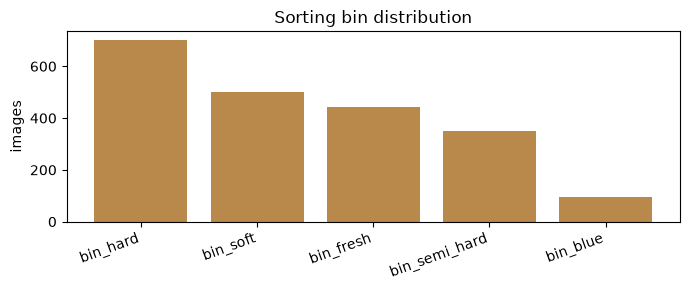

imbalance max/min: 7.4


In [4]:
# The 5 sorting bins: this is the label sent to the arm
subset, bins, _ = build_label_space(rows, 'bin')
counts = collections.Counter(r['bin'] for r in subset)

fig, ax = plt.subplots(figsize=(7, 3))
names = sorted(counts, key=counts.get, reverse=True)
ax.bar(names, [counts[n] for n in names], color='#b8894a')
ax.set_ylabel('images'); ax.set_title('Sorting bin distribution')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

print('imbalance max/min:', round(max(counts.values()) / min(counts.values()), 1))

### What the data looks like

Important for what follows: the Food Recognition instances are **crops** of meal
scenes — cheese on a plate, on bread, in a hand — not isolated pieces on a belt.

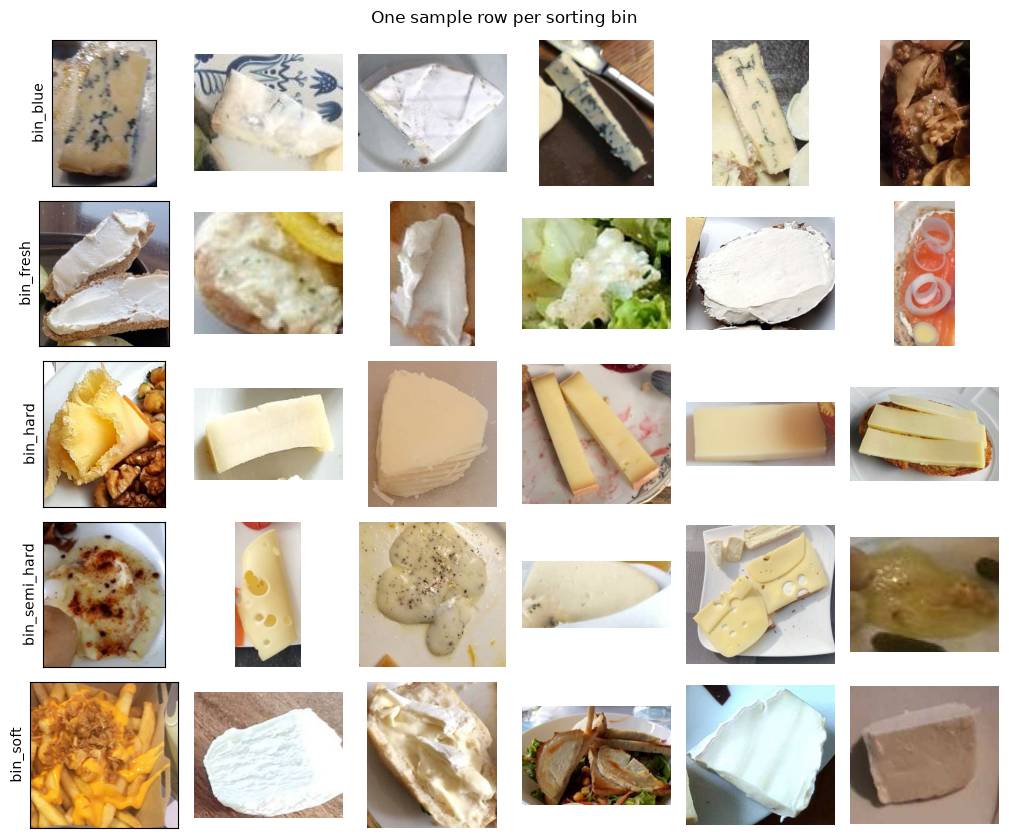

In [5]:
def grid(lines, per_row=6, size=1.7, title=None):
    fig, axes = plt.subplots(len(lines), per_row,
                             figsize=(per_row * size, len(lines) * size))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.axis('off')
    for y, (name, items) in enumerate(lines):
        for x, r in enumerate(items[:per_row]):
            with Image.open(PROJECT / 'data/processed' / r['path']) as im:
                axes[y, x].imshow(im.convert('RGB'))
        axes[y, 0].set_ylabel(name)
        axes[y, 0].axis('on')
        axes[y, 0].set_xticks([]); axes[y, 0].set_yticks([])
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

random.seed(0)
by_bin = collections.defaultdict(list)
for r in subset:
    by_bin[r['bin']].append(r)
grid([(b, random.sample(by_bin[b], 6)) for b in sorted(by_bin)],
     title='One sample row per sorting bin')

## 2. The trap: CHEESE-HIDB only holds 9 wheels

The 378 CHEESE-HIDB images are not 378 cheeses. They are **9 wheels**, each
photographed 42 times on a turntable — blocks of consecutive DSC numbers, exactly
42 per block.

Splitting per image puts the same wheel in train **and** in test. The model memorises
the wheel instead of learning the cheese: the first run reported **100% macro-F1 by
epoch 13**, a number with no predictive value whatsoever.

The manifest's `group` column is therefore the wheel, and the splits respect it.

In [6]:
hidb = [r for r in rows if r['source'] == 'cheese_hidb']

blocks = collections.defaultdict(list)
for r in hidb:
    blocks[r['label']].append(int(re.search(r'(\d+)', Path(r['src_path']).stem).group(1)))

for label in sorted(blocks):
    ns = sorted(blocks[label]); runs = []; start = prev = ns[0]
    for n in ns[1:]:
        if n - prev > 1:
            runs.append((start, prev)); start = n
        prev = n
    runs.append((start, prev))
    print(f'{label:24s} {len(ns):3d} img = ' +
          '  '.join(f'{a}-{b} ({b - a + 1} views)' for a, b in runs))

extra_hard__nottarget     84 img = 1771-1812 (42 views)  1814-1855 (42 views)
extra_hard__target        42 img = 1900-1941 (42 views)
hard__nottarget           84 img = 1943-1984 (42 views)  1986-2027 (42 views)
hard__target              42 img = 1857-1898 (42 views)
semi_hard__nottarget      84 img = 2029-2070 (42 views)  2072-2113 (42 views)
semi_hard__target         42 img = 1727-1766 (40 views)  1768-1769 (2 views)


In [7]:
wheels = collections.defaultdict(set)
for r in hidb:
    wheels[r['group']].add(r['split'])

print(f'{len(wheels)} wheels identified\n')
for w in sorted(wheels):
    print(f'  {w:34s} -> {sorted(wheels[w])[0]}')
print('\nwheels straddling two splits:',
      sum(1 for v in wheels.values() if len(v) > 1))

10 wheels identified

  extra_hard__nottarget#wheel0       -> test
  extra_hard__nottarget#wheel1       -> train
  extra_hard__target#wheel0          -> val
  hard__nottarget#wheel0             -> val
  hard__nottarget#wheel1             -> train
  hard__target#wheel0                -> test
  semi_hard__nottarget#wheel0        -> train
  semi_hard__nottarget#wheel1        -> val
  semi_hard__target#wheel0           -> test
  semi_hard__target#wheel1           -> train

wheels straddling two splits: 0


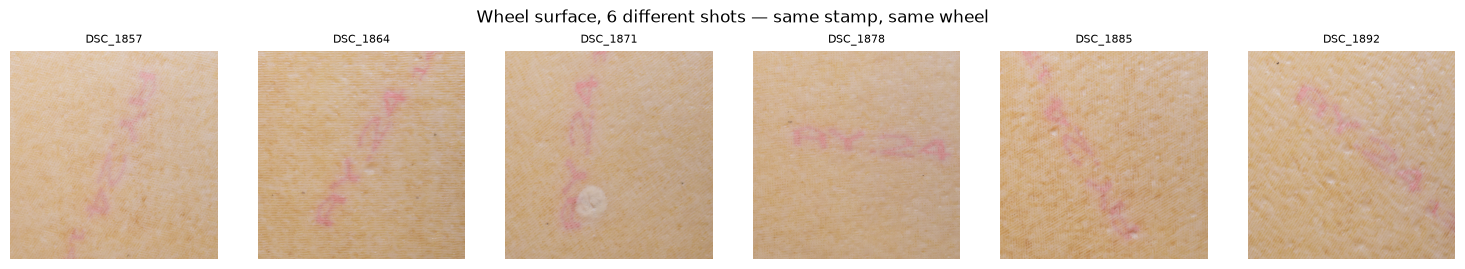

In [8]:
# Visual proof: 6 views of hard__target, the same pink ink stamp rotating
target = sorted([r for r in hidb if r['label'] == 'hard__target'],
                key=lambda r: r['src_path'])[::7][:6]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, r in zip(axes, target):
    with Image.open(PROJECT / r['src_path']) as im:
        w, h = im.size
        ax.imshow(im.crop((w//2 - 700, h//2 - 700, w//2 + 700, h//2 + 700)))
    ax.set_title(Path(r['src_path']).stem, fontsize=8); ax.axis('off')
fig.suptitle('Wheel surface, 6 different shots — same stamp, same wheel')
plt.tight_layout(); plt.show()

**Direct consequence on what can be measured:**

| task | wheels per class | verdict |
|---|---|---|
| `hidb_product_ripeness` (6 cls) | 1 to 2 | not measurable, everything goes to train |
| `hidb_product` (3 cls) | 3 to 4 | a per-wheel split holds → **the only measurable one** |

The other use for HIDB, probably the most valuable here: 42 views around a wheel is
photogrammetry material for texturing the 3D belt asset in Omniverse.

## 3. How the models perform

ConvNeXt-Base pretrained on ImageNet-22k, 384 px, AdamW + cosine, bf16.
The retained checkpoint is the best **validation macro-F1** — not accuracy, which
rides on the majority classes.

In [9]:
results = {d.parent.name: json.loads(d.read_text())
           for d in sorted((PROJECT / 'runs').glob('*/results.json'))}

print(f"{'head':22s} {'top-1':>8s} {'top-5':>8s} {'macro-F1':>9s} {'best ep':>9s}")
print('-' * 60)
for name, r in results.items():
    t, b = r.get('test'), r['best_val']
    star = ' <- shipped' if name == 'sim_type13' else ''
    print(f"{name:22s} {t['top1']:8.3f} {t['top5']:8.3f} "
          f"{t['macro_f1']:9.3f} {b['epoch']:5d}/{len(r['history'])}{star}")

print()
print('These are NOT comparable to each other: different tasks,')
print('different class counts, different test sets.')
print('See the vault note "Model comparison" for matched pairs.')

head                      top-1    top-5  macro-F1   best ep
------------------------------------------------------------
bin                       0.789    1.000     0.767     9/60
fr_cheese_type            0.591    0.903     0.499    14/60
hidb_product              0.758    1.000     0.727     3/40
sim_bin                   0.763    1.000     0.709    17/30
sim_type                  0.694    0.927     0.588    18/20
sim_type11                0.679    0.913     0.561    19/20
sim_type13                0.728    0.904     0.600    19/20 <- shipped
variety                   0.524    0.704     0.353    38/60

These are NOT comparable to each other: different tasks,
different class counts, different test sets.
See the vault note "Model comparison" for matched pairs.


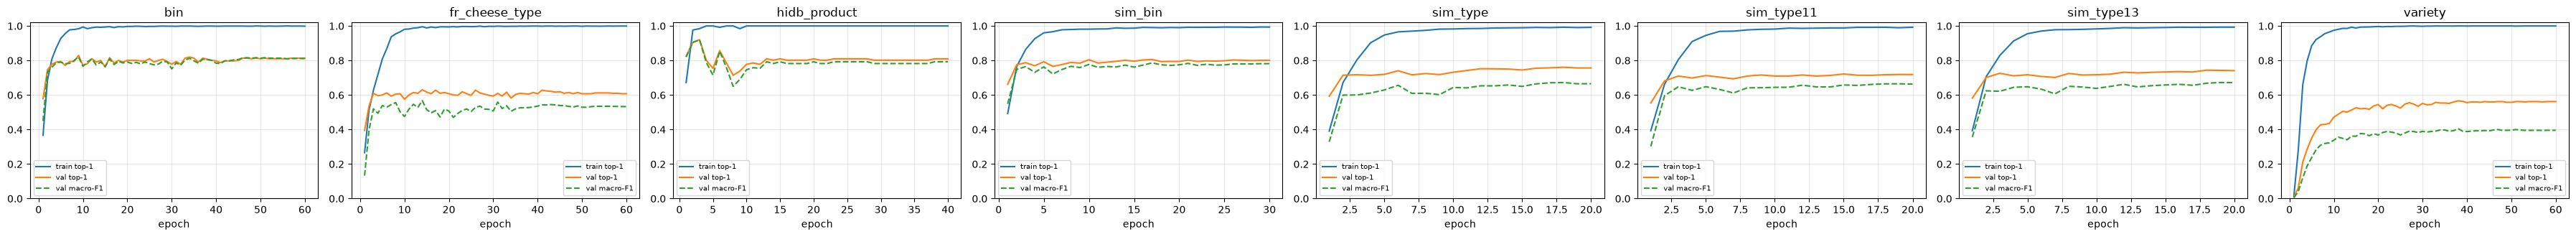

Every head peaks early — epochs 3, 9, 14, 17, 38 out of 30 or 60.
ConvNeXt-Base memorises 1.5-7k images in under fifteen passes;
the remaining epochs change nothing in the retained checkpoint.


In [10]:
# Learning curves
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(4.5 * len(results), 3.4), squeeze=False)
    for ax, (name, r) in zip(axes[0], results.items()):
        h = r['history']
        ep = [e['epoch'] for e in h]
        ax.plot(ep, [e['train_top1'] for e in h], label='train top-1')
        ax.plot(ep, [e['val_top1'] for e in h], label='val top-1')
        ax.plot(ep, [e['val_macro_f1'] for e in h], label='val macro-F1', ls='--')
        ax.set_title(name); ax.set_xlabel('epoch'); ax.set_ylim(0, 1.02)
        ax.grid(alpha=.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

print('Every head peaks early — epochs 3, 9, 14, 17, 38 out of 30 or 60.')
print('ConvNeXt-Base memorises 1.5-7k images in under fifteen passes;')
print('the remaining epochs change nothing in the retained checkpoint.')

In [11]:
# Per-class breakdown of the shipped model
pc = results['sim_type13']['per_class']
classes = [c for c in pc if c not in ('accuracy', 'macro avg', 'weighted avg')]
print(f"  {'class':20s} {'precision':>10s} {'recall':>8s} {'F1':>7s} {'support':>8s}")
print('-' * 58)
for c in sorted(classes, key=lambda c: -pc[c]['support']):
    m = pc[c]
    flag = '  <- never recognised' if m['f1-score'] == 0 else ''
    print(f"  {c:20s} {m['precision']:10.3f} {m['recall']:8.3f} "
          f"{m['f1-score']:7.3f} {int(m['support']):8d}{flag}")

  class                 precision   recall      F1  support
----------------------------------------------------------
  hard_cheese               0.745    0.881   0.807      430
  not_cheese                0.858    0.828   0.843      285
  soft_cheese               0.661    0.765   0.709      260
  semi_hard_cheese          0.525    0.503   0.514      145
  empty                     1.000    1.000   1.000      135
  cottage_cheese            0.790    0.983   0.876      115
  fresh_cheese              0.583    0.445   0.505      110
  raclette_cheese           0.654    0.700   0.676      100
  goat_cheese_soft          0.478    0.259   0.336       85
  cream_cheese              0.455    0.267   0.336       75
  blue_mould_cheese         0.917    0.508   0.653       65
  emmental_cheese           0.773    0.425   0.548       40
  processed_cheese          0.000    0.000   0.000        5  <- never recognised


## 4. The inference call, as the simulation will make it

This is the contract the arm-control pipeline consumes.

In [12]:
from predict import CheeseClassifier

ckpt = PROJECT / 'runs/bin/best.pt'
clf = CheeseClassifier(ckpt, min_confidence=0.55)
clf.warmup()
print(f'task {clf.task} | {len(clf.classes)} classes | input {clf.img_size} px')
print('bins:', clf.classes)

task bin | 5 classes | input 384 px
bins: ['bin_blue', 'bin_fresh', 'bin_hard', 'bin_semi_hard', 'bin_soft']


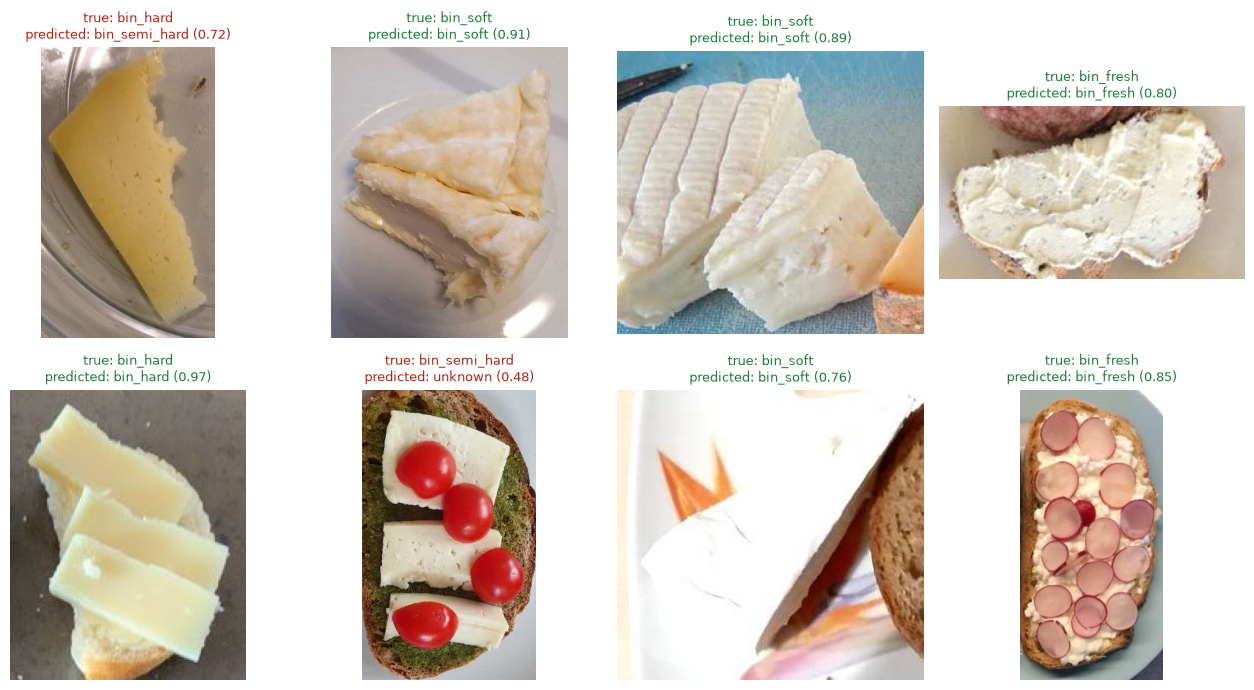

In [13]:
# On a few test images the model has never seen
test = [r for r in subset if r['split'] == 'test']
random.seed(3)
sample = random.sample(test, 8)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, r in zip(axes.ravel(), sample):
    with Image.open(PROJECT / 'data/processed' / r['path']) as im:
        im = im.convert('RGB')
        pred = clf.predict(im)
        ax.imshow(im)
    ok = pred.label == r['bin']
    ax.set_title(f"true: {r['bin']}\npredicted: {pred.label} ({pred.confidence:.2f})",
                 fontsize=9, color='#1a7f37' if ok else '#b42318')
    ax.axis('off')
plt.tight_layout(); plt.show()

### The confidence threshold, and why it matters

Below `min_confidence` the label becomes `"unknown"`: **the arm should let the piece
pass** rather than drop it in a random bin. A wrong bin costs more than a missed
cycle, so this threshold is tuned on that trade-off, not on accuracy.

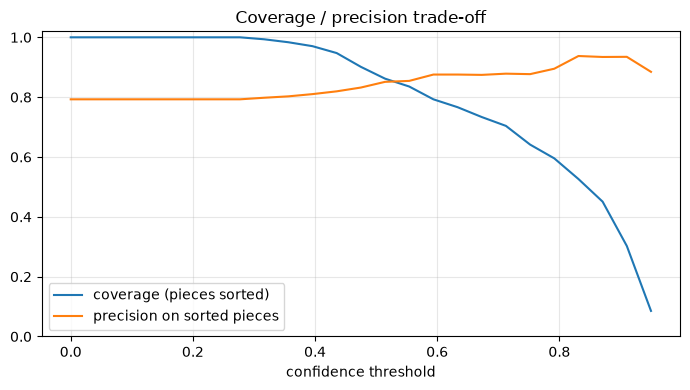

threshold 0.0: 100.0% of pieces sorted, 79.3% correctly
threshold 0.5: 87.8% of pieces sorted, 84.6% correctly
threshold 0.7: 71.7% of pieces sorted, 87.2% correctly
threshold 0.9: 32.9% of pieces sorted, 93.0% correctly


In [14]:
batches = [test[i:i+64] for i in range(0, len(test), 64)]
pred_labels, confs, truths = [], [], []
for batch in batches:
    images = [Image.open(PROJECT / 'data/processed' / r['path']).convert('RGB') for r in batch]
    for p, r in zip(clf.predict_batch(None, frames=images), batch):
        pred_labels.append(p.topk[0][0]); confs.append(p.topk[0][1]); truths.append(r['bin'])
    for im in images:
        im.close()

confs = np.array(confs)
correct = np.array([p == t for p, t in zip(pred_labels, truths)])

thresholds = np.linspace(0, 0.95, 25)
coverage = [(confs >= s).mean() for s in thresholds]
precision = [correct[confs >= s].mean() if (confs >= s).any() else np.nan for s in thresholds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, coverage, label='coverage (pieces sorted)')
ax.plot(thresholds, precision, label='precision on sorted pieces')
ax.set_xlabel('confidence threshold'); ax.set_ylim(0, 1.02)
ax.grid(alpha=.3); ax.legend(); ax.set_title('Coverage / precision trade-off')
plt.tight_layout(); plt.show()

for s in (0.0, 0.5, 0.7, 0.9):
    m = confs >= s
    if m.any():
        print(f'threshold {s:.1f}: {m.mean():5.1%} of pieces sorted, '
              f'{correct[m].mean():5.1%} correctly')

### Latency — does it keep up with the belt?

In [15]:
dummy = np.random.randint(0, 255, (720, 1280, 3), dtype=np.uint8)
clf.warmup(5)

import time
for n in (1, 4, 8):
    boxes = [(100 + 60*i, 100, 400 + 60*i, 400) for i in range(n)]
    t0 = time.perf_counter()
    for _ in range(20):
        clf.predict_batch(dummy, boxes=boxes)
    dt = (time.perf_counter() - t0) / 20
    print(f'{n} piece(s) per frame: {dt*1e3:6.1f} ms  ->  {1/dt:5.1f} frames/s')

1 piece(s) per frame:   13.8 ms  ->   72.5 frames/s


4 piece(s) per frame:   29.8 ms  ->   33.5 frames/s


8 piece(s) per frame:   50.3 ms  ->   19.9 frames/s


## 5. From real photo to Isaac Sim render

The section-3 models are trained on **real photographs**: cheese on a plate, on a
board, held in a hand. The belt camera will see something else entirely. This section
turns the photos into renders of the target scene, so that training and inference
share a domain.

| stage | what it produces |
|---|---|
| polygon cutout (`src/cutouts.py`) | an RGBA piece with a **real silhouette**, no rectangular background |
| USD scene (`sim/render_belt.py`) | belt, rails, slats, plate, lighting, camera |
| multi-view render | 5 views per piece, with domain randomisation |

### Stage 1 — the cutout

The normalised images are **rectangles**: the cheese plus the bread, plate or hand
around it. Dropping those into a plate would give "a photo lying in a plate".
Food Recognition annotates each instance with a polygon, so the polygon becomes the
alpha channel and the outline becomes the cheese's own.

No model, no SAM — the contours were already in the data, drawn by human annotators.
Which is also why some cutouts carry bread along: the annotator included it.

In [16]:
cutouts = list(csv.DictReader(open(PROJECT / 'data/processed/cutouts/manifest.csv')))
by_bin_cut = collections.defaultdict(list)
for d in cutouts:
    by_bin_cut[d['bin']].append(d)

print(f'{len(cutouts)} RGBA cutouts')
for b in sorted(by_bin_cut):
    print(f'  {b:16s} {len(by_bin_cut[b]):4d}')

2400 RGBA cutouts
  bin_blue           92
  bin_fresh         417
  bin_hard          678
  bin_semi_hard     338
  bin_soft          475
  not_cheese        400


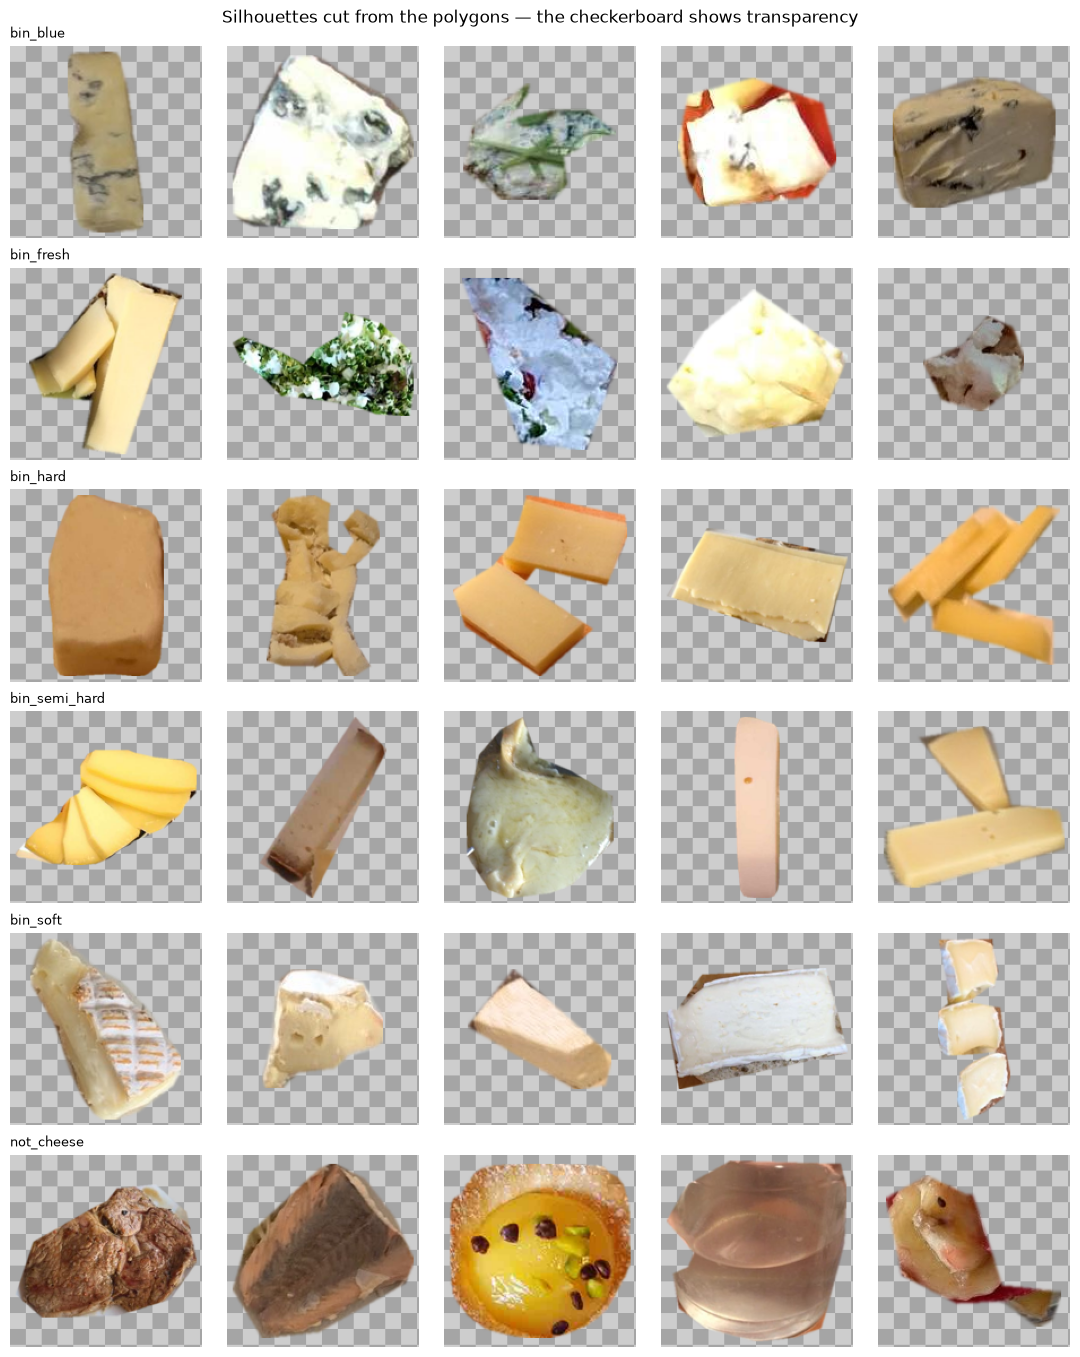

In [17]:
# checkerboard, to make the alpha channel visible
def on_checkerboard(im, T=170, step=14):
    bg = Image.new('RGB', (T, T), (205, 205, 205))
    for y in range(0, T, step):
        for x in range(0, T, step):
            if (x // step + y // step) % 2:
                bg.paste((165, 165, 165), (x, y, x + step, y + step))
    im = im.convert('RGBA').copy()
    im.thumbnail((T - 10, T - 10))
    bg.paste(im, ((T - im.width) // 2, (T - im.height) // 2), im)
    return bg

random.seed(5)
bin_names = sorted(by_bin_cut)
fig, axes = plt.subplots(len(bin_names), 5, figsize=(11, 2.3 * len(bin_names)))
for y, b in enumerate(bin_names):
    for x, d in enumerate(random.sample(by_bin_cut[b], 5)):
        with Image.open(PROJECT / 'data/processed' / d['path']) as im:
            axes[y, x].imshow(on_checkerboard(im))
        axes[y, x].axis('off')
    axes[y, 0].set_title(b, loc='left', fontsize=9)
fig.suptitle('Silhouettes cut from the polygons — the checkerboard shows transparency')
plt.tight_layout(); plt.show()

### Stages 2 and 3 — the scene and the renders

The piece is applied to a quad lying in the plate, with the alpha used as a cutout
threshold (`UsdPreviewSurface.opacityThreshold`). Every view randomises: piece
rotation and position, camera azimuth / elevation / distance / focal length, lamp
position, intensity and tint, dome intensity, and the plate and belt shades.

The plate is a **96-segment mesh**, not a USD cylinder: the default tessellation
produced a decagon, a hard edge the model would have learned as a background cue
rather than as cheese.

12355 renders, 3191 distinct pieces


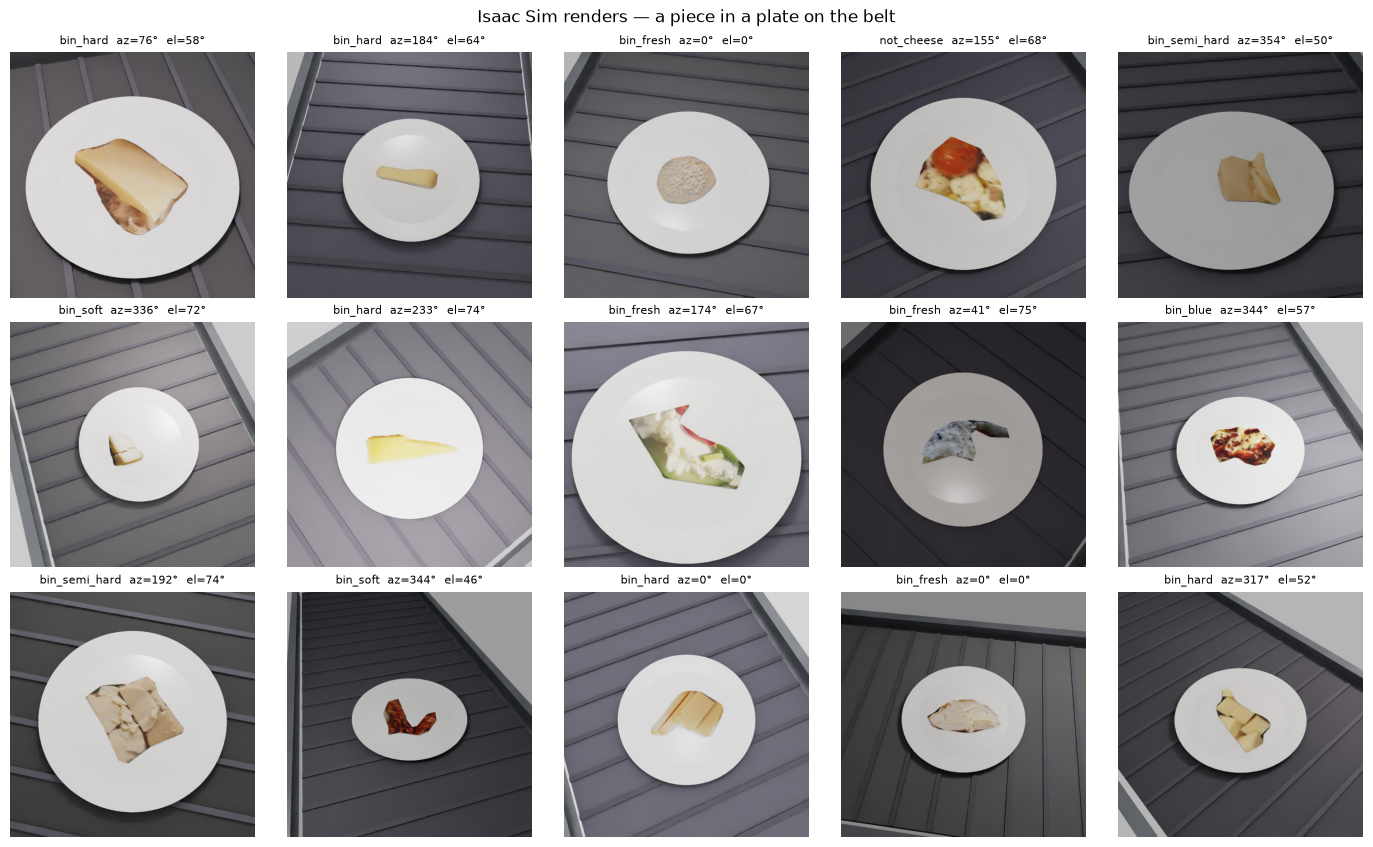

In [18]:
# the final manifest: images converted to 512 px JPEG, splits by piece
sim_rows = load_manifest(PROJECT / 'data/processed/manifest_sim.csv')
renders = [{'file': r['path'], 'bin': r['label'], 'group': r['group'],
            'view': json.loads(r['extra'])['view'],
            'azimuth': json.loads(r['extra'])['azimut'],
            'elevation': json.loads(r['extra'])['elevation']} for r in sim_rows]
print(f"{len(renders)} renders, {len({r['group'] for r in renders})} distinct pieces")

random.seed(4)
fig, axes = plt.subplots(3, 5, figsize=(14, 8.6))
for ax, r in zip(axes.ravel(), random.sample(renders, 15)):
    with Image.open(PROJECT / 'data/processed' / r['file']) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title(f"{r['bin']}  az={r['azimuth']:.0f}°  el={r['elevation']:.0f}°", fontsize=8)
    ax.axis('off')
fig.suptitle('Isaac Sim renders — a piece in a plate on the belt')
plt.tight_layout(); plt.show()

### The comparison, piece by piece

Each row follows **the same piece**: the original photo, its cutout silhouette, then
three renders under different angles and lighting.

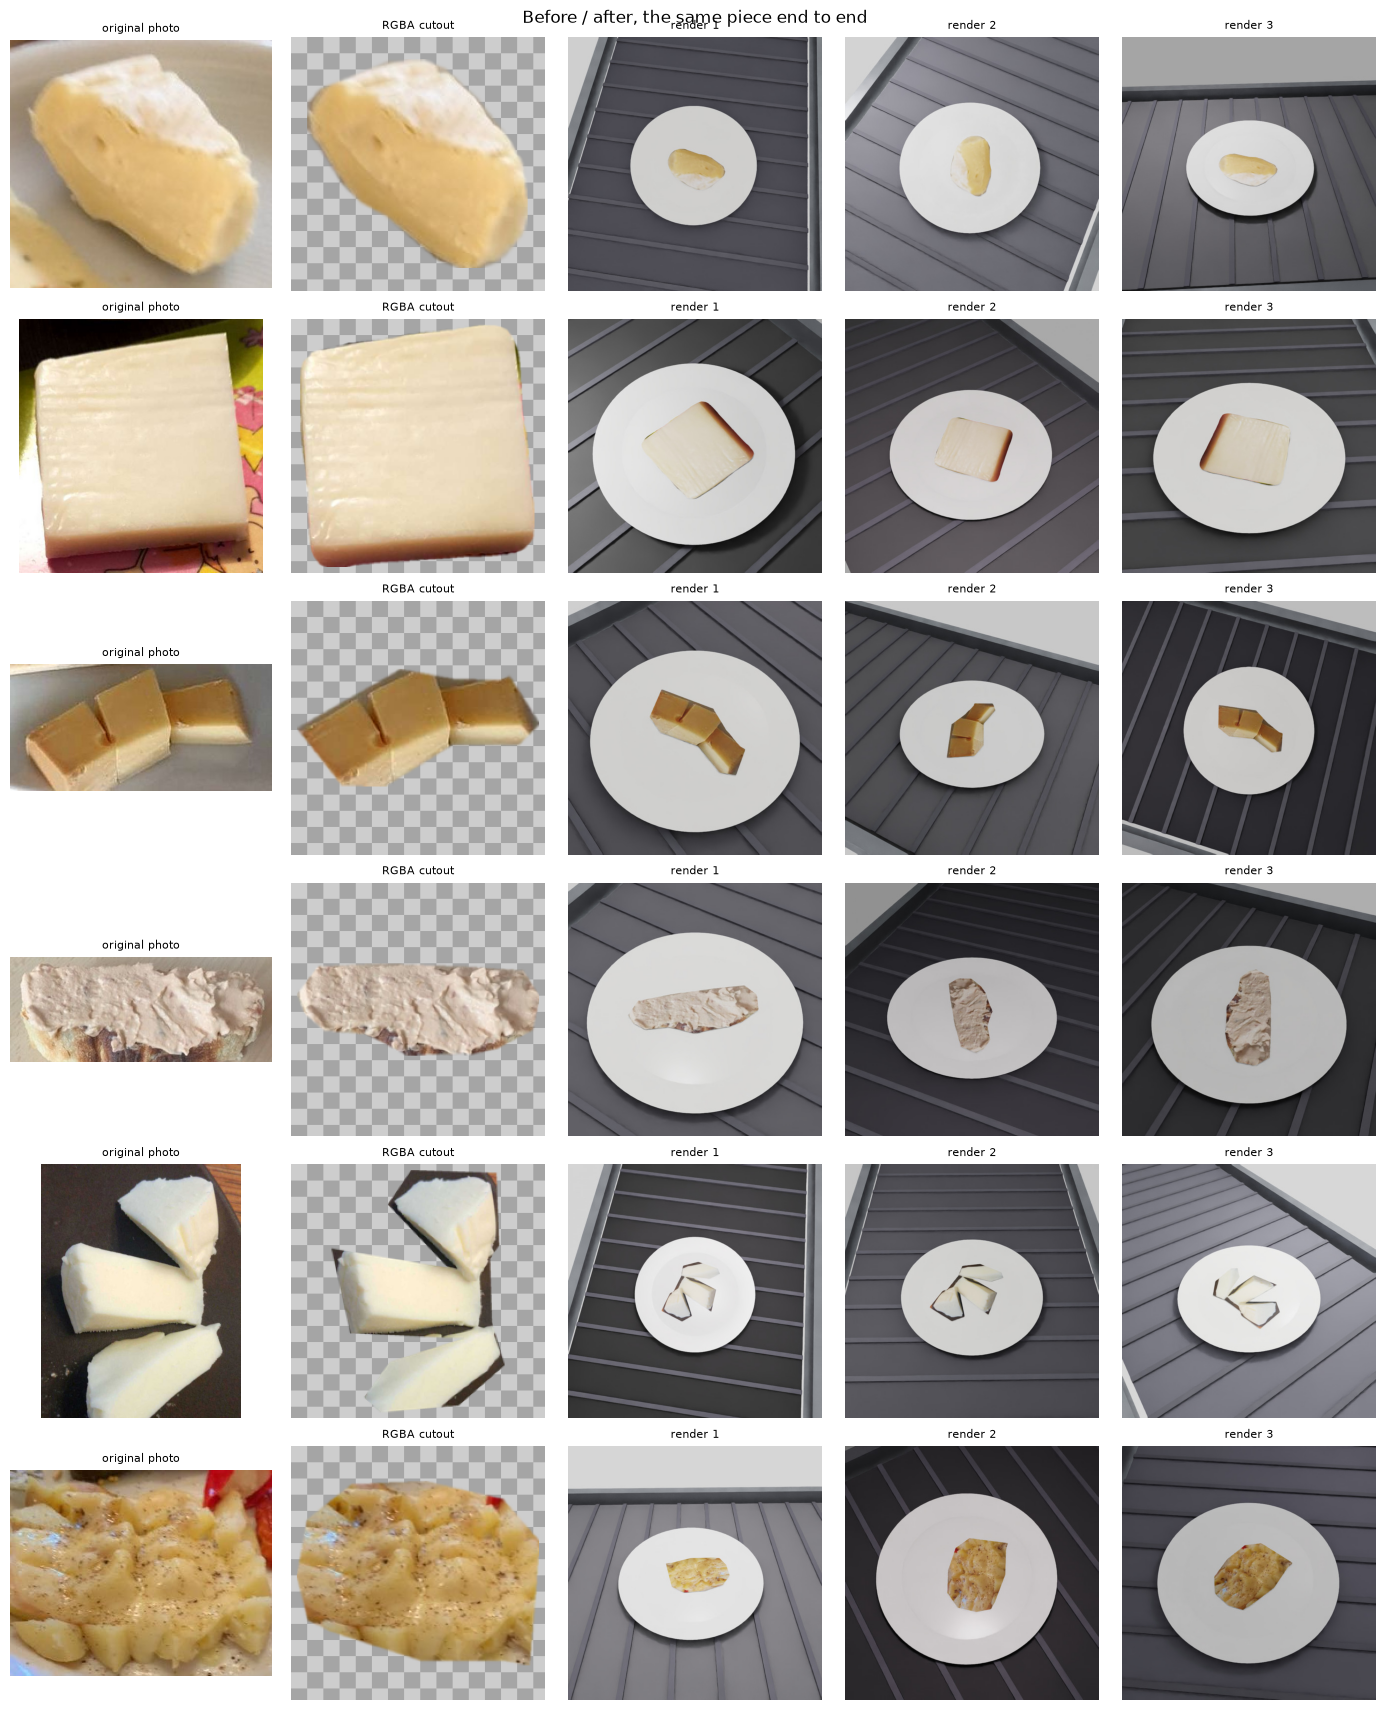

In [19]:
manifest_by_uid = {r['uid']: r for r in rows}
cut_by_uid = {d['uid']: d for d in cutouts}
by_piece = collections.defaultdict(list)
for r in renders:
    by_piece[r['group']].append(r)

random.seed(8)
candidates = [u for u in by_piece if u in manifest_by_uid and u in cut_by_uid]
pieces = random.sample(candidates, 6)
fig, axes = plt.subplots(len(pieces), 5, figsize=(14, 2.9 * len(pieces)))
for y, uid in enumerate(pieces):
    with Image.open(PROJECT / 'data/processed' / manifest_by_uid[uid]['path']) as im:
        axes[y, 0].imshow(im.convert('RGB'))
    axes[y, 0].set_title('original photo', fontsize=8)
    with Image.open(PROJECT / 'data/processed' / cut_by_uid[uid]['path']) as im:
        axes[y, 1].imshow(on_checkerboard(im, T=220))
    axes[y, 1].set_title('RGBA cutout', fontsize=8)
    for x, r in enumerate(sorted(by_piece[uid], key=lambda r: r['view'])[:3]):
        with Image.open(PROJECT / 'data/processed' / r['file']) as im:
            axes[y, 2 + x].imshow(im.convert('RGB'))
        axes[y, 2 + x].set_title(f'render {x + 1}', fontsize=8)
    for ax in axes[y]:
        ax.axis('off')
fig.suptitle('Before / after, the same piece end to end')
plt.tight_layout(); plt.show()

### Two things to keep in mind

**The piece stays flat.** It is a decal with a correct silhouette, not a volume: no
thickness, no self-shadowing, no specular response of its own. The visible shading
comes from the original photograph. If the demo scene places real 3D assets on the
belt, the gap moves rather than disappears.

**Views of one piece are correlated.** Three views of the same cheese are not three
samples: it is one object under three angles. Splitting them across train and test
would recreate the leak fixed on the CHEESE-HIDB wheels in section 2. The render
manifest's `group` field carries the source piece uid — that is what drives the split,
not the filename.

And an arithmetic reminder: adding angles **adds no cheese**. There are still 1,909
distinct pieces, seen from more viewpoints. That helps the model become viewpoint
invariant; it does not teach it new varieties.

### What the render score measures — and what it does not

Read this before quoting the `sim_bin` number anywhere.

**What it measures:** the ability to classify these 1,909 source pieces under varied
angles, lighting and framing. That is a genuine measure of **viewpoint invariance**,
and the splits are clean — the 5 views of a piece stay on the same side of the line.

**What it does not measure:** performance on the demo scene. Train and test share the
same source photos, the same renderer, the same plate, the same belt, and the same
approximation — flat decals, not volumes. A high score here says nothing more about
the real belt than the photo-trained `bin` does.

**Three known biases, most serious first:**

1. **Lighting is baked into the photo.** Each cutout carries the lighting of its
   original shot — flash, window, fluorescent — layered on top of the scene's own.
   Worse, that photographic style correlates with the class: the model can learn JPEG
   noise or white balance instead of cheese.
2. **The piece is flat.** No thickness, no self-shadowing, no specular of its own.
3. **The background is always the same.** One plate, one belt. The model can lean on
   them invisibly.

**What would settle it**, most valuable first: labelled frames from the actual Isaac
scene (even 100 would *measure* the gap instead of assuming it); then real 3D assets
instead of decals — `sim/render_belt.py` is ready for that, only the quad needs to
become a mesh.

## 6. Try the model

The shipped model is **`sim_type13`** — one network, three answers:

| output | example | what it is for |
|---|---|---|
| `cheese_type` | `emmental_cheese` | display |
| `bin` | `bin_hard` | **drives the arm** |
| `status` | `ok` / `empty` / `not_cheese` / `uncertain` | **test this first** |

`bin` is `None` in every non-`ok` case, by design, so a distracted caller cannot sort
a piece by accident.

The bin confidence is the **sum** of the probabilities of all types in that bin, so it
is systematically at least as high as the type confidence — trust the bin more than
the name.

In [20]:
from predict import CheeseSorter, CheeseClassifier, BIN_OF_TYPE, REJECT_STATUS

THRESHOLD = 0.55      # below this, status becomes 'uncertain' and the arm lets it pass

sorter = CheeseSorter(PROJECT / 'runs/sim_type13/best.pt', min_confidence=THRESHOLD)
sorter.warmup()
print(f'{len(sorter.types)} classes, input {sorter.img_size} px')
print('bins        :', sorter.bins)
print('reject types:', sorter.reject_types)

# the photo-trained baseline, for comparison
baseline = CheeseClassifier(PROJECT / 'runs/bin/best.pt', min_confidence=THRESHOLD)
baseline.warmup()

sim_rows = load_manifest(PROJECT / 'data/processed/manifest_sim.csv')
sim_test = [r for r in sim_rows if r['split'] == 'test']
print(f"\n{len(sim_test)} test renders, "
      f"{len({r['group'] for r in sim_test})} distinct pieces")

13 classes, input 384 px
bins        : ['bin_blue', 'bin_fresh', 'bin_hard', 'bin_semi_hard', 'bin_soft']
reject types: ['empty', 'not_cheese']



1850 test renders, 478 distinct pieces


### The draw — re-run this cell for a new example

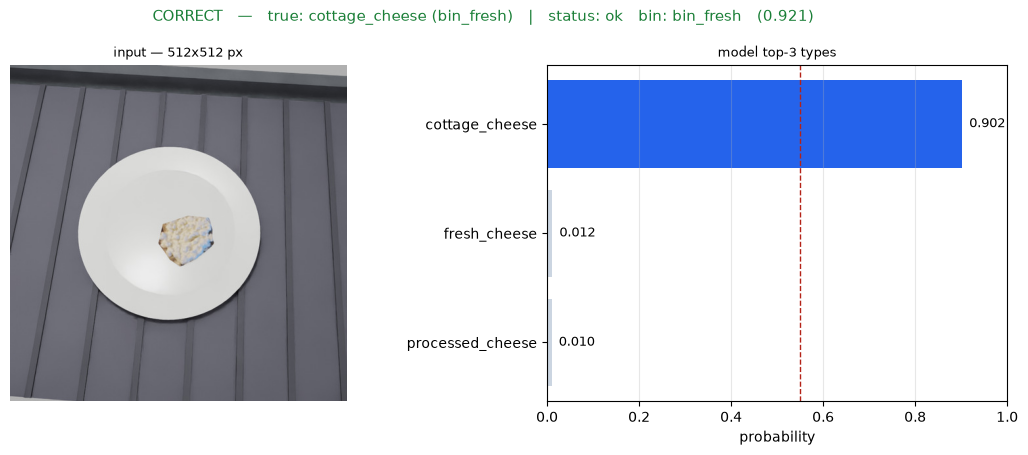

status          : ok
bin             : bin_fresh   (0.921)
cheese_type     : cottage_cheese   (0.902)
latency         : 49.7 ms

# what the arm control receives:
{
  "status": "ok",
  "bin": "bin_fresh",
  "bin_confidence": 0.920541584957391,
  "cheese_type": "cottage_cheese",
  "type_confidence": 0.9023844003677368,
  "topk_types": [
    [
      "cottage_cheese",
      0.9023844003677368
    ],
    [
      "fresh_cheese",
      0.011716351844370365
    ],
    [
      "processed_cheese",
      0.010359859094023705
    ]
  ],
  "latency_ms": 49.72850898047909
}


In [21]:
row = random.choice(sim_test)
truth_type = row['fr_type']
truth_bin  = BIN_OF_TYPE.get(truth_type, truth_type)

with Image.open(PROJECT / 'data/processed' / row['path']) as im:
    im = im.convert('RGB')
    r = sorter.predict(im)
    thumb = im.copy()

predicted = r.bin if r.actionable else r.status
ok = predicted == truth_bin
colour = '#1a7f37' if ok else ('#b54708' if not r.actionable else '#b42318')

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.6))
left.imshow(thumb); left.axis('off')
left.set_title(f'input — {thumb.size[0]}x{thumb.size[1]} px', fontsize=9)

names  = [n for n, _ in r.topk_types][::-1]
scores = [s for _, s in r.topk_types][::-1]
right.barh(names, scores,
           color=['#2563eb' if n == truth_type else '#cbd5e1' for n in names])
right.axvline(THRESHOLD, color='#b42318', ls='--', lw=1)
right.set_xlim(0, 1); right.set_xlabel('probability'); right.grid(axis='x', alpha=.3)
for i, s in enumerate(scores):
    right.text(s + 0.015, i, f'{s:.3f}', va='center', fontsize=9)
right.set_title('model top-3 types', fontsize=9)

verdict = 'CORRECT' if ok else ('ABSTAINED / REJECTED' if not r.actionable else 'WRONG')
fig.suptitle(f'{verdict}   —   true: {truth_type} ({truth_bin})   |   '
             f'status: {r.status}   bin: {r.bin}   ({r.bin_confidence:.3f})',
             color=colour, fontsize=11)
plt.tight_layout(); plt.show()

print(f'status          : {r.status}')
print(f'bin             : {r.bin}   ({r.bin_confidence:.3f})')
print(f'cheese_type     : {r.cheese_type}   ({r.type_confidence:.3f})')
print(f'latency         : {r.latency_ms:.1f} ms')
print()
print('# what the arm control receives:')
print(json.dumps(r.as_dict(), indent=2, ensure_ascii=False))

### The reject classes — can it say "do not pick this up"?

Re-run to draw from `empty` (nothing on the belt) or `not_cheese` (a real object that
is not cheese, taken from 400 other Food Recognition classes).

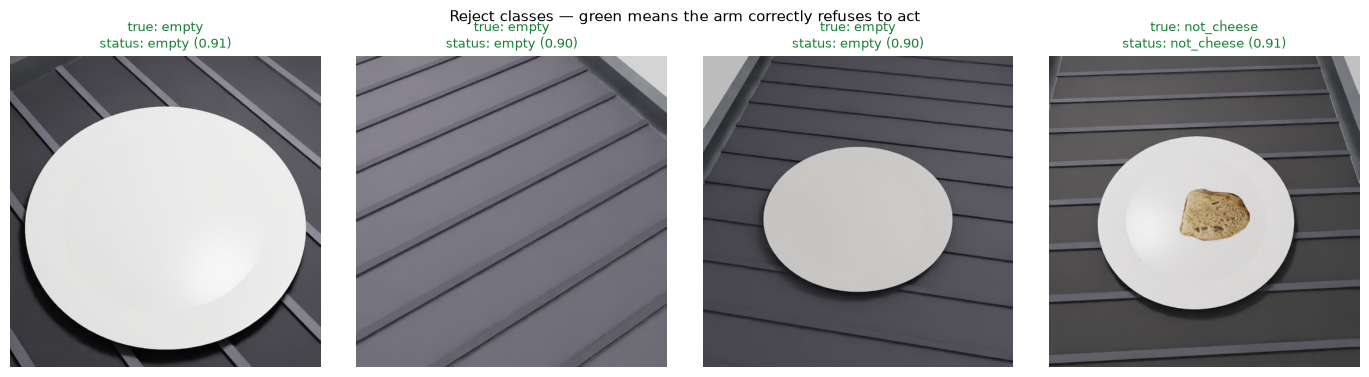

In [22]:
rejects = [r for r in sim_test if r['fr_type'] in REJECT_STATUS]
sample = random.sample(rejects, 4)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, row in zip(axes, sample):
    with Image.open(PROJECT / 'data/processed' / row['path']) as im:
        im = im.convert('RGB')
        r = sorter.predict(im)
        ax.imshow(im)
    ok = r.status == row['fr_type']
    ax.set_title(f"true: {row['fr_type']}\nstatus: {r.status} ({r.bin_confidence:.2f})",
                 fontsize=9, color='#1a7f37' if ok else '#b42318')
    ax.axis('off')
fig.suptitle('Reject classes — green means the arm correctly refuses to act', fontsize=11)
plt.tight_layout(); plt.show()

### Pick an image with dropdowns

Run this cell once: choose the **class** and the **image**, and the prediction updates
on its own.

In [23]:
import ipywidgets as w
from IPython.display import display

POOL = [(r['fr_type'], r['path'], r['uid']) for r in sim_test]

class_dd = w.Dropdown(options=sorted({c for c, _, _ in POOL}), description='class:',
                      layout=w.Layout(width='360px'))
image_dd = w.Dropdown(description='image:', layout=w.Layout(width='620px'))
out = w.Output()


def refresh_images(*_):
    items = [(uid, path) for c, path, uid in POOL if c == class_dd.value]
    image_dd.options = sorted(items)[:400]


def run(*_):
    if not image_dd.value:
        return
    path = PROJECT / 'data/processed' / image_dd.value
    truth_type = class_dd.value
    truth_bin = BIN_OF_TYPE.get(truth_type, truth_type)
    with Image.open(path) as im:
        im = im.convert('RGB')
        r = sorter.predict(im)
        thumb = im.copy()
    with out:
        out.clear_output(wait=True)
        fig, (l, rt) = plt.subplots(1, 2, figsize=(11, 4.4))
        l.imshow(thumb); l.axis('off'); l.set_title(Path(image_dd.value).name, fontsize=8)
        names  = [n for n, _ in r.topk_types][::-1]
        scores = [s for _, s in r.topk_types][::-1]
        rt.barh(names, scores,
                color=['#2563eb' if n == truth_type else '#cbd5e1' for n in names])
        rt.axvline(THRESHOLD, color='#b42318', ls='--', lw=1)
        rt.set_xlim(0, 1); rt.set_xlabel('probability'); rt.grid(axis='x', alpha=.3)
        rt.set_title('model top-3 types', fontsize=9)
        predicted = r.bin if r.actionable else r.status
        ok = predicted == truth_bin
        fig.suptitle(f'true: {truth_type} ({truth_bin})   |   status: {r.status}   '
                     f'bin: {r.bin}   ({r.bin_confidence:.3f})   |   {r.latency_ms:.1f} ms',
                     color='#1a7f37' if ok else '#b42318', fontsize=11)
        plt.tight_layout(); plt.show()


class_dd.observe(lambda c: (refresh_images(), run()), names='value')
image_dd.observe(run, names='value')
refresh_images()
display(w.VBox([class_dd, image_dd, out]))
run()

### Run inference on a specific image

Put a path in `IMAGE` and re-run — relative to `data/processed/` or absolute.
This is the exact call the robot pipeline makes.

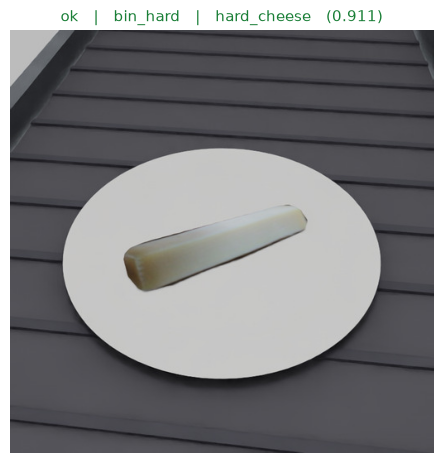

# what the arm control receives:
{
  "status": "ok",
  "bin": "bin_hard",
  "bin_confidence": 0.9106151238083839,
  "cheese_type": "hard_cheese",
  "type_confidence": 0.9044371843338013,
  "topk_types": [
    [
      "hard_cheese",
      0.9044371843338013
    ],
    [
      "not_cheese",
      0.01034610066562891
    ],
    [
      "semi_hard_cheese",
      0.009429436177015305
    ]
  ],
  "latency_ms": 52.722761989571154
}

# and how it should branch:
if r.actionable:  place_in_bin(r.bin)
else:             signal(r.status)


In [24]:
IMAGE = 'images/sim_belt/bin_hard/bin_hard__0419fd646e9cfbfb__v0.jpg'

path = Path(IMAGE)
if not path.is_absolute():
    path = PROJECT / 'data/processed' / IMAGE
assert path.exists(), f'not found: {path}'

with Image.open(path) as im:
    im = im.convert('RGB')
    r = sorter.predict(im)
    thumb = im.copy()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(thumb); ax.axis('off')
ax.set_title(f'{r.status}   |   {r.bin}   |   {r.cheese_type}   ({r.bin_confidence:.3f})',
             fontsize=11, color='#1a7f37' if r.actionable else '#b54708')
plt.show()

print('# what the arm control receives:')
print(json.dumps(r.as_dict(), indent=2, ensure_ascii=False))
print()
print('# and how it should branch:')
print('if r.actionable:  place_in_bin(r.bin)')
print('else:             signal(r.status)')

## 7. What is left on the simulation side

**The domain gap is not measured.** Every number above comes from real photographs or
from renders built out of them. What the Isaac Sim camera will actually see — an
isolated piece on a belt, synthetic lighting — is different, and 0.763 says nothing
about what it will give there. This is the largest remaining risk on this block.
Section 8 sends frames from a live Isaac Sim scene through the model for the first
time, but on eleven picked pieces: it probes the gap, it does not measure it.

**One architectural recommendation.** `bin_semi_hard` and `bin_blue` sit around 0.57 F1
with recall under 0.50 in the render-trained model. Both need fine detail — paste
grain, blue veining — and the piece is too small in the frame to keep it. So do not
feed the whole frame to the classifier: detect the piece on the belt first
(background subtraction is enough, the belt is uniform), crop, then classify the crop.
`predict_batch(frame, boxes=[...])` already expects that shape.

**Levers, most effective first:**

1. capture a few hundred frames rendered in the actual sim, label them, and fine-tune
   briefly — this closes the most gap;
2. domain randomisation on the Omniverse side: lighting, textures, poses, background;
3. training augmentation is already aggressive, but it does not replace the first two.

For integration, `src/export.py` produces an ONNX plus a `_sidecar.json` (class order,
input size, exact preprocessing) if you prefer TensorRT over the PyTorch runtime.

## 8. The model on a sorting line

A full line built in Isaac Sim, **routed by the model**. A piece arrives on the belt,
stops under the inspection camera, `sim_type13` says what it is, and the diverter for
that class lifts and pushes it onto its own lane. One lane per output class: the five
bins, plus `REJECT` for every status that is not `ok`.

Nothing is scripted — the lane is whatever `CheeseSorter.predict()` returns for the
frame the camera just took. The scene is `sim/sorting_line.py`; the model runs on the
host behind `sim/sort_server.py`, because the Isaac Sim image has neither torch nor
timm. The inspection station reuses the belt, the plate and the cutout quad of
`sim/render_belt.py`, so what the camera sees is the domain the model was trained on.

### The video

<video controls loop width="960" src="/notebook/files/cheese/sim/cheese_sorting.mp4"></video>

*Empty player?* The URL above is the one the Jupyter web app serves. On the host, or if
the player stays blank, run the cell below (`Shift`+`Enter`): it embeds the file straight
into the cell output.

In [ ]:
from IPython.display import Video, Markdown, display

VIDEO = PROJECT / 'sim/cheese_sorting.mp4'
if VIDEO.exists():
    # embed=True : la video part dans la sortie de la cellule, donc elle s'affiche
    # aussi bien sur l'hote que dans la webapp, sans dependre du routage des URL
    display(Video(str(VIDEO), embed=True, width=960,
                  html_attributes='controls loop style="border-radius:8px"'))
else:
    display(Markdown(f'`{VIDEO}` absent — relancer `sync_jupyter.sh` sur l\'hote, '
                     'ou refabriquer avec `sim/sorting_line.py` puis `sim/make_video.py`.'))

### What it routed, piece by piece

In [ ]:
run = json.loads((PROJECT / 'sim/cheese_sorting.json').read_text())
print(f"{run['traitees']} pieces inspectees, {run['justes']} dans le bac attendu\n")
for d in run['decisions']:
    dec = d['decision']
    marque = 'ok  ' if d['voie'] == d['verite_voie'] else 'RATE'
    print(f"{marque} {d['label'][:28]:30s} -> {dec['cheese_type']:20s} "
          f"{d['voie']:14s} {dec['bin_confidence']:.3f}  {dec['latency_ms']:.0f} ms")
print('\npar sortie :', run['compteurs'])

> **The eleven pieces are picked.** `sim/pick_demo_pieces.py` keeps cheeses the model
> already handles on training-domain renders, so 11/11 shows the line working — not the
> model's error rate, which is still 0.754 on the bin decision (section 3). What it does
> show: a frame from a live Isaac Sim scene reaches the model and comes back as a lane
> in 29–48 ms, and a couscous salad ends up in `REJECT` instead of a cheese bin.

## 9. The arm picks what the model decided

Same line, one block further down: the camera's verdict now drives a **Franka FR3**.
A plate arrives, the belt indexes it under the inspection station, `sim_type13` names
the cheese, and the arm takes the plate to the lane for that class.

Two models, two trades, neither knows the other exists. The classifier returns a bin and
has never seen an arm. The arm receives **an integer** — never an image, never a class.
The meeting point is `sim/pick_line.py`; the cell itself is `sim/pick_cell.py`.

**What drives the arm here is the reference state machine, not the learned policy.**
The HUD says so, top right. The PPO policy of `sim/train_pick.py` grips, lifts and
carries the plate — but it has not learned to set it down, and section 9.1 says exactly
where it stands. The routing decisions in this video are the model's, all eight of them;
the arm is the actuator.

Three things the cell had to be taught, each of which cost a full training run:

* **A plate a parallel gripper can actually hold.** 180 mm gripped by the rim hangs
  90 mm from its centre of mass — 0.12 N.m on two jaws, it tips and the cheese falls. At
  68 mm the gripper straddles it and the grip line runs through the centre of mass.
* **A reward that pays progress, not state.** Carrying paid ~10 per step for as long as
  you liked; putting the plate down paid 80 once and ended the episode. Loitering was
  worth ten times succeeding, and 29 M steps went into learning exactly that. The reward
  is now the change in a potential, which is zero when nothing happens.
* **An arm that can reach its own lanes.** Joint 1 of an FR3 stops at ±157°, so there is
  a 46° sector behind it where nothing is reachable. Mounted facing the belt, that sector
  sat in the middle of the lane arc: `bin_soft` and `bin_fresh` were unreachable.

### The video

<video controls loop width="960" src="/notebook/files/cheese/sim/cheese_picking.mp4"></video>

*Empty player?* Same as section 8 — run the cell below to embed the file into the output.

In [ ]:
from IPython.display import Video, Markdown, display

BRAS = PROJECT / 'sim/cheese_picking.mp4'
if BRAS.exists():
    display(Video(str(BRAS), embed=True, width=960,
                  html_attributes='controls loop style="border-radius:8px"'))
else:
    display(Markdown(f'`{BRAS}` absent — relancer `sync_jupyter.sh` sur l\'hote, '
                     'ou refabriquer avec `sim/pick_line.py` puis `sim/make_video.py`.'))


### What the arm did, piece by piece

In [ ]:
bras = json.loads((PROJECT / 'sim/cheese_picking.json').read_text())
print(f"{bras['traitees']} pieces  |  {bras['posees']} assiettes posees  |  "
      f"{bras['justes']} dans le bac attendu  |  pilote : {bras['pilote']}\n")
for r in bras['resultats']:
    marque = 'ok  ' if r.get('juste') else 'RATE'
    print(f"{marque} {r['verite_label'][:26]:28s} -> {r.get('cheese_type', '?'):20s} "
          f"{r['voie']:14s} {r.get('bin_confidence', 0):.3f}  "
          f"{r.get('latency_ms', 0):4.0f} ms  geste : {r.get('issue', '?')}")
print('\npar sortie :', bras['compteurs'])


### 9.1 — Where the arm's policy stands

Honest reading of the curve. **The policy learns to hold, not to put down.**

While the curriculum feeds it episodes that start with the plate already gripped, it
keeps the plate — up to 33% of cells holding, and it carries it towards the lane. When
that curriculum fades out (iteration 500), holding falls to zero: the policy never
learned to take a plate off the belt by itself, and it has never once completed a
deposit.

What the day did buy is an environment that is no longer lying. A grip that holds
perfectly still for 400 steps, plates that no longer get ejected by a scaled collider,
a conveyor that actually conveys, PhysX buffers sized for 1024 cells instead of silently
dropping contacts, and a reward that cannot be farmed by doing nothing. Those were all
real bugs, and each of them alone was enough to make training impossible.

What is left is the exploration problem the shaping has not yet solved: bringing the
plate down onto the lane and opening the jaws. The reference state machine does it 2
times out of 8 above, so the task is feasible in this cell — it is the policy that has
not found it yet.

In [ ]:
import matplotlib.pyplot as plt

hist = json.loads((PROJECT / 'runs/pick_fr3/results.json').read_text())['historique']
it = [e['iteration'] for e in hist]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(it, [100 * e['part_tenue'] for e in hist], label='assiette tenue')
ax[0].plot(it, [100 * e['reussite'] for e in hist], label='assiette posee')
ax[0].set_xlabel('iteration'); ax[0].set_ylabel('%'); ax[0].legend()
ax[0].set_title('ce que la politique sait faire')
ax[1].plot(it, [e['recompense'] for e in hist], color='tab:green')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('recompense / pas')
ax[1].set_title('recompense de progres')
for a in ax:
    a.grid(alpha=.3); a.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f"{len(hist)} iterations, {len(hist) * 24 * 1024 / 1e6:.1f} M pas")
print(f"tenue max  : {100 * max(e['part_tenue'] for e in hist):.1f} %")
print(f"posee max  : {100 * max(e['reussite'] for e in hist):.1f} %")


## Appendix — how this notebook runs in the web app

The `jupyter-notebook` container only mounts `/opt/nvidia/launchpad/jupyter-notebook`
(seen as `/workspace`), so it cannot see `/home/nvidia/hpe/cheese`. Two things were
done to make the notebook work anyway:

**1. The packages, installed into the container venv from the host:**

```bash
docker exec jupyter-notebook /opt/venv/bin/pip install \
    torch torchvision --index-url https://download.pytorch.org/whl/cu124
docker exec jupyter-notebook /opt/venv/bin/pip install \
    timm pillow numpy pandas scikit-learn matplotlib
```

`/opt/venv` is the venv running JupyterLab, so it is the web app's default `python3`
kernel — nothing else to select. The container gets both H100s through CDI, and
`torch.cuda.is_available()` returns `True` there.

**2. The project, copied into the shared area:**

```bash
/home/nvidia/hpe/cheese/sync_jupyter.sh      # -> /workspace/cheese, ~2.6 GB
```

A copy rather than a mount: the two directories sit on different filesystems, so hard
links are not possible.

### Two limitations to remember

- `/workspace/cheese` is a **snapshot**. After retraining, re-run `sync_jupyter.sh` or
  the notebook will read stale checkpoints.
- The `pip install` lives in the container: it survives `docker restart`, but a
  `docker compose up` that **recreates** the container wipes it.

To remove both limitations, mount the project directly in
`/opt/nvidia/launchpad/docker-compose/docker-compose.yml`:

```yaml
    volumes:
      - /opt/nvidia/launchpad/jupyter-notebook:/workspace
      - /home/nvidia/hpe/cheese:/home/nvidia/hpe/cheese
```
